# Student Living Cost Analysis

## Problem overview
The HSGA is looking to push for stipend increase within the various College of Medicine departments. They need to provide substantial and convincing information to the Office of Graduate Education (OGE) to inform this adjustments.

## Data source
**91** students got to take part in a google forms survey between **2025/08/20 11:02:56 AM AST** -  **2025/09/05 10:41:37 AM AST** . The aim of the survey was to get a glimpse into students cost of living.  Data was then uploaded as a csv file.

## Methodology
1.  Loading data and preview

1.  Exploratory Data Analysis

1.  Conclusion, with recommendations 

In [1]:
#Importing necessary libraries to load and manipulate our data
import pandas as pd
import sqlite3

In [2]:
#Loading our data into a DataFrame
df = pd.read_csv('Data/Student Living Cost Survey 2025-2026.csv')

In [3]:
df.rename(columns=lambda x: x.strip().replace(" ", "_").replace("?", ""), inplace=True)

We are going to read our data from SqLite DB for better presentation.

In [4]:
#Creating a connection with our Survey DB
conn = sqlite3.connect('Data/Survey.db')

In [5]:
#Writing df into sqlite table
df.to_sql("Survey", conn, if_exists="replace", index=False)


In [6]:
#Selecting all columns in the Survey table
query = """
        SELECT *
          FROM Survey;
"""

In [7]:
#Displaying our data
pd.read_sql(query,conn)

,Timestamp,What_is_your_program,Are_you_an_international_student,What_was_your_individual_monthly_housing_payment_during_the_previous_year_(Base_cost;_no_utilities),What_is_your_individual_monthly_housing_payment_for_the_upcoming_year_(Base_cost;_no_utilities),"What_is_your_monthly_cost_on_utilities_(gas/electric/water/trash/internet/laundry_services/renter's_insurance,_etc.)",Do_you_consider_your_neighborhood_to_be_a_safe_environment_Elaborate_on_your_point.,"If_you_answered_""No""_in_the_previous_question,_considering_the_perceived_level_of_safety_in_your_current_neighborhood,_what_would_be_the_expected_monthly_rental_cost_of_an_apartment_in_a_location_deemed_secure","On_average,_how_much_time_do_you_spend_one-way_commuting_on_a_daily_basis_Please_specify_walk,_drive,_and/or_public_transportation.","What_is_your_average_monthly_cost_to_commute_to_work_Please_include_gas,_Metro_bus,_and/or_taxi/Uber_prices.","What_is_your_average_yearly_expenditure_incurred_for_travel_to_your_home_or_for_vacation_purposes_Please_include_gas,_Metro_bus,_taxi/Uber,_and/or_airfare_prices).","If_you_own_a_car,_what_is_your_average_yearly_cost_for_car_maintenance/car_payments/car_insurance/parking_passes",What_is_your_average_monthly_(not_weekly)_expenditure_on_groceries_and_dining_out,What_is_your_average_monthly_expense_for_health-associated_costs_(medications/copays/procedures/etc.),"For_pet_owners,_what_is_the_average_monthly_expenditure_on_pet-related_costs","If_applicable,_approximately_how_much_do_you_spend_on_average_per_month_to_support_dependents_(children,_elderly_parents,_etc.)","If_applicable,_what_are_your_average_miscellaneous_expenses_per_year_that_are_essential_but_were_not_mentioned_in_the_above_categories_(e.g._Clothing_etc.)_Please_list_each_expense_category_in_your_answer.","In_the_past_12_months,_which_of_the_following_trade-offs_have_you_made_to_meet_living_expenses_(Select_all_that_apply.)"
0,2025/08/20 11:02:56 AM AST,Molecular and Developmental Biology,Yes,1640,1840,400,yes,None,10 mins drive,120,800,2000,200,200,None,0,4000,None
1,2025/08/20 11:02:58 AM AST,Biomedical Informatics/Biostats,Yes,1800,1850,250,yes,None,15,100,4000,3000,2000,800,800,None,3000,None
2,2025/08/20 11:05:59 AM AST,"Molecular Genetics, Biochemistry and Microbiology",No,1200,1350,200,Yes. I had to move out of a very unsafe neighb...,None,20min driving,50,1500 (fly back home 2x a year for holidays),"5000 (car payments, insurance, parking pass)",300,500 (many of my medications not covered by stu...,30,None,100 clothing \n4800 therapy not covered by ins...,None
3,2025/08/20 11:07:21 AM AST,Molecular and Developmental Biology,Yes,1400,1400,300,yes,None,drive - 20 mins,40,2500,2000,400,100,150,None,"clothing, subscriptions, gym memberships, tech...",None
4,2025/08/20 11:09:05 AM AST,Epidemiology,Yes,600,625,150,Fairly safe ; although there have been inciden...,900,20 mins,100,1300,2000,150,100,None,None,Clothing - 400,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,2025/09/04 7:36:16 AM AST,"Molecular, Cellular and Biochemical Pharmacology",Yes,550,550,10,Not really. I receive many alerts.,None,20 mins walk,100,5000,None,300,0,None,None,2000,Chose a lower-cost apartment despite safety/qu...
87,2025/09/05 8:33:07 AM AST,Genetic Counseling,No,1685,1700,$300,"Yes, there are lots of families",None,"20-25 minutes driving, 12 minute walk from garage",~$50 gas,Not sure,Estimate $1000,$500 groceries,$0 (on Ohio Medicaid),None,$500,Unsure,None of the above
88,2025/09/05 9:08:11 AM AST,Molecular and Developmental Biology,No,1150,1185,250,"Yes, I live in East Walnut Hills, and the area...",None,15 minute drive,$70,$1000,$1500,$100,$40,None,None,Clothing - $500\nhousehold items/toiletries/cl...,"Reduced food quality/quantity (e.g., cheaper/l..."
89,2025/09/05 10:22:00 AM AST,Biomedical Informatics/Biostats,No,2000,2000,300,Yes,None,$4 - driving (not including parking),$128,$500,$1270,$250,$150,$100,None,clothing/personal items - m

In [8]:
#Selecting rows with international students
international = pd.read_sql("""
                SELECT Are_you_an_international_student
                  FROM Survey
                 WHERE Are_you_an_international_student = 'Yes';
""", conn )

In [9]:
#Checking number of international students
international.count()

Are_you_an_international_student    26
dtype: int64

In [10]:
#Inspecting number of non-international students
non = pd.read_sql("""
                SELECT Are_you_an_international_student
                  FROM Survey
                 WHERE Are_you_an_international_student = 'No';
""", conn )
non.count()

Are_you_an_international_student    65
dtype: int64

Great!! So out of 91 students, we have 65 non-international, making international 26

In [11]:
df.columns

Index(['Timestamp', 'What_is_your_program', 'Are_you_an_international_student',
       'What_was_your_individual_monthly_housing_payment_during_the_previous_year_(Base_cost;_no_utilities)',
       'What_is_your_individual_monthly_housing_payment_for_the_upcoming_year_(Base_cost;_no_utilities)',
       'What_is_your_monthly_cost_on_utilities_(gas/electric/water/trash/internet/laundry_services/renter's_insurance,_etc.)',
       'Do_you_consider_your_neighborhood_to_be_a_safe_environment_Elaborate_on_your_point.',
       'If_you_answered_"No"_in_the_previous_question,_considering_the_perceived_level_of_safety_in_your_current_neighborhood,_what_would_be_the_expected_monthly_rental_cost_of_an_apartment_in_a_location_deemed_secure',
       'On_average,_how_much_time_do_you_spend_one-way_commuting_on_a_daily_basis_Please_specify_walk,_drive,_and/or_public_transportation.',
       'What_is_your_average_monthly_cost_to_commute_to_work_Please_include_gas,_Metro_bus,_and/or_taxi/Uber_prices.',
  

In [12]:
#Checking for missing values
df.isna().sum()

Timestamp                                                                                                                                                                                                             0
What_is_your_program                                                                                                                                                                                                  0
Are_you_an_international_student                                                                                                                                                                                      0
What_was_your_individual_monthly_housing_payment_during_the_previous_year_(Base_cost;_no_utilities)                                                                                                                   1
What_is_your_individual_monthly_housing_payment_for_the_upcoming_year_(Base_cost;_no_utilities)                                         

In [13]:
# Converting relevant columns to numeric, coercing errors for non-numeric entries
df['What_was_your_individual_monthly_housing_payment_during_the_previous_year_(Base_cost;_no_utilities)'] = pd.to_numeric(
    df['What_was_your_individual_monthly_housing_payment_during_the_previous_year_(Base_cost;_no_utilities)'], errors='coerce')
df['What_is_your_individual_monthly_housing_payment_for_the_upcoming_year_(Base_cost;_no_utilities)'] = pd.to_numeric(
    df['What_is_your_individual_monthly_housing_payment_for_the_upcoming_year_(Base_cost;_no_utilities)'], errors='coerce')
df['What_is_your_monthly_cost_on_utilities_(gas/electric/water/trash/internet/laundry_services/renter\'s_insurance,_etc.)'] = pd.to_numeric(
    df["What_is_your_monthly_cost_on_utilities_(gas/electric/water/trash/internet/laundry_services/renter's_insurance,_etc.)"].replace('[\$,]', '', regex=True), errors='coerce')
df['What_is_your_average_monthly_(not_weekly)_expenditure_on_groceries_and_dining_out'] = pd.to_numeric(
    df['What_is_your_average_monthly_(not_weekly)_expenditure_on_groceries_and_dining_out'].replace('[\$,]', '', regex=True), errors='coerce')


## Exploratory Data Analysis

In [14]:
# EDA: Summary statistics
eda_summary = df[[
    'What_was_your_individual_monthly_housing_payment_during_the_previous_year_(Base_cost;_no_utilities)',
    'What_is_your_individual_monthly_housing_payment_for_the_upcoming_year_(Base_cost;_no_utilities)',
    "What_is_your_monthly_cost_on_utilities_(gas/electric/water/trash/internet/laundry_services/renter's_insurance,_etc.)",
    'What_is_your_average_monthly_(not_weekly)_expenditure_on_groceries_and_dining_out'
]].describe()

print("Summary statistics for key cost categories:")
print(eda_summary)

Summary statistics for key cost categories:
       What_was_your_individual_monthly_housing_payment_during_the_previous_year_(Base_cost;_no_utilities)  \
count                                          65.000000                                                     
mean                                         1075.876923                                                     
std                                           459.606303                                                     
min                                             0.000000                                                     
25%                                           800.000000                                                     
50%                                           980.000000                                                     
75%                                          1350.000000                                                     
max                                          3000.000000                    

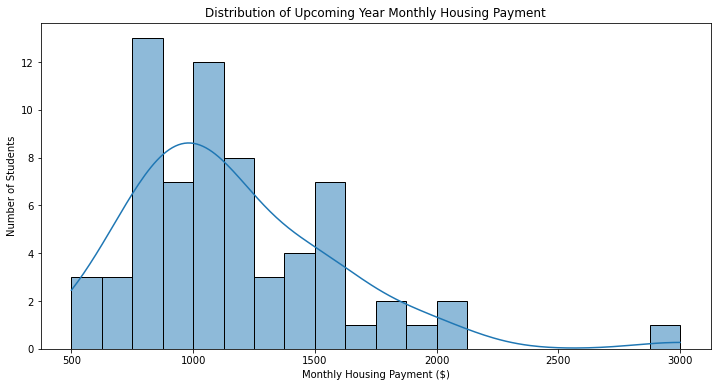

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.histplot(df['What_is_your_individual_monthly_housing_payment_for_the_upcoming_year_(Base_cost;_no_utilities)'], bins=20, kde=True)
plt.title('Distribution of Upcoming Year Monthly Housing Payment')
plt.xlabel('Monthly Housing Payment ($)')
plt.ylabel('Number of Students')
plt.show()

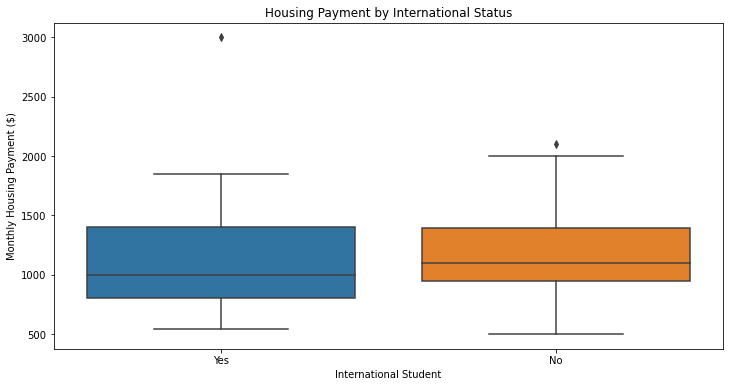

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Are_you_an_international_student',
            y='What_is_your_individual_monthly_housing_payment_for_the_upcoming_year_(Base_cost;_no_utilities)')
plt.title('Housing Payment by International Status')
plt.xlabel('International Student')
plt.ylabel('Monthly Housing Payment ($)')
plt.show()

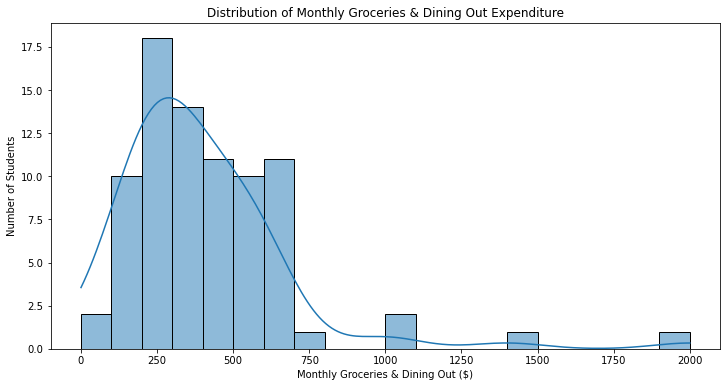

In [17]:
plt.figure(figsize=(12, 6))
sns.histplot(df['What_is_your_average_monthly_(not_weekly)_expenditure_on_groceries_and_dining_out'], bins=20, kde=True)
plt.title('Distribution of Monthly Groceries & Dining Out Expenditure')
plt.xlabel('Monthly Groceries & Dining Out ($)')
plt.ylabel('Number of Students')
plt.show()

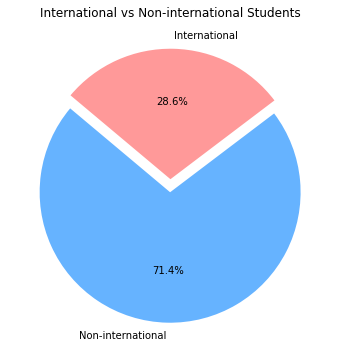

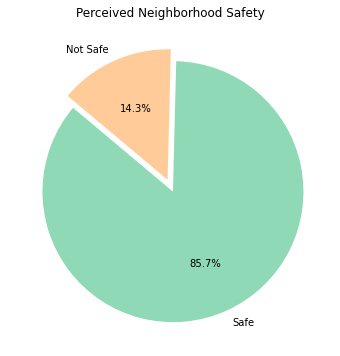

In [18]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Pie chart: International vs Non-international students
plt.figure(figsize=(6, 6))
labels = ['Non-international', 'International']
sizes = [len(non), len(international)]
colors = ['#66b3ff', '#ff9999']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0.05))
plt.title('International vs Non-international Students')
plt.show()

# Pie chart: Safe vs Not Safe Neighborhood
plt.figure(figsize=(6, 6))
safe_counts = df['Do_you_consider_your_neighborhood_to_be_a_safe_environment_Elaborate_on_your_point.'].str.lower().str.contains('yes|safe').value_counts()
labels = ['Safe', 'Not Safe']
sizes = [safe_counts.get(True, 0), safe_counts.get(False, 0)]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#8fd9b6', '#ffcc99'], explode=(0.05, 0.05))
plt.title('Perceived Neighborhood Safety')
plt.show()



Trade-offs made by students to meet living expenses (count):
 cheaper/less nutritious                                                                                                                                                                                                                            41
 medical                                                                                                                                                                                                                                            13
 phone                                                                                                                                                                                                                                              13
 skipped meals);Delayed medical/dental care or prescriptions due to cost;Used credit cards/loans or sold belongings to cover essentials                                                               

<ipython-input-19-3a3cd65fba04>:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()
C:\Users\jerry\anaconda3\envs\learn-env\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: constrained_layout not applied.  At least one axes collapsed to zero width or height.
  fig.canvas.print_figure(bytes_io, **kw)


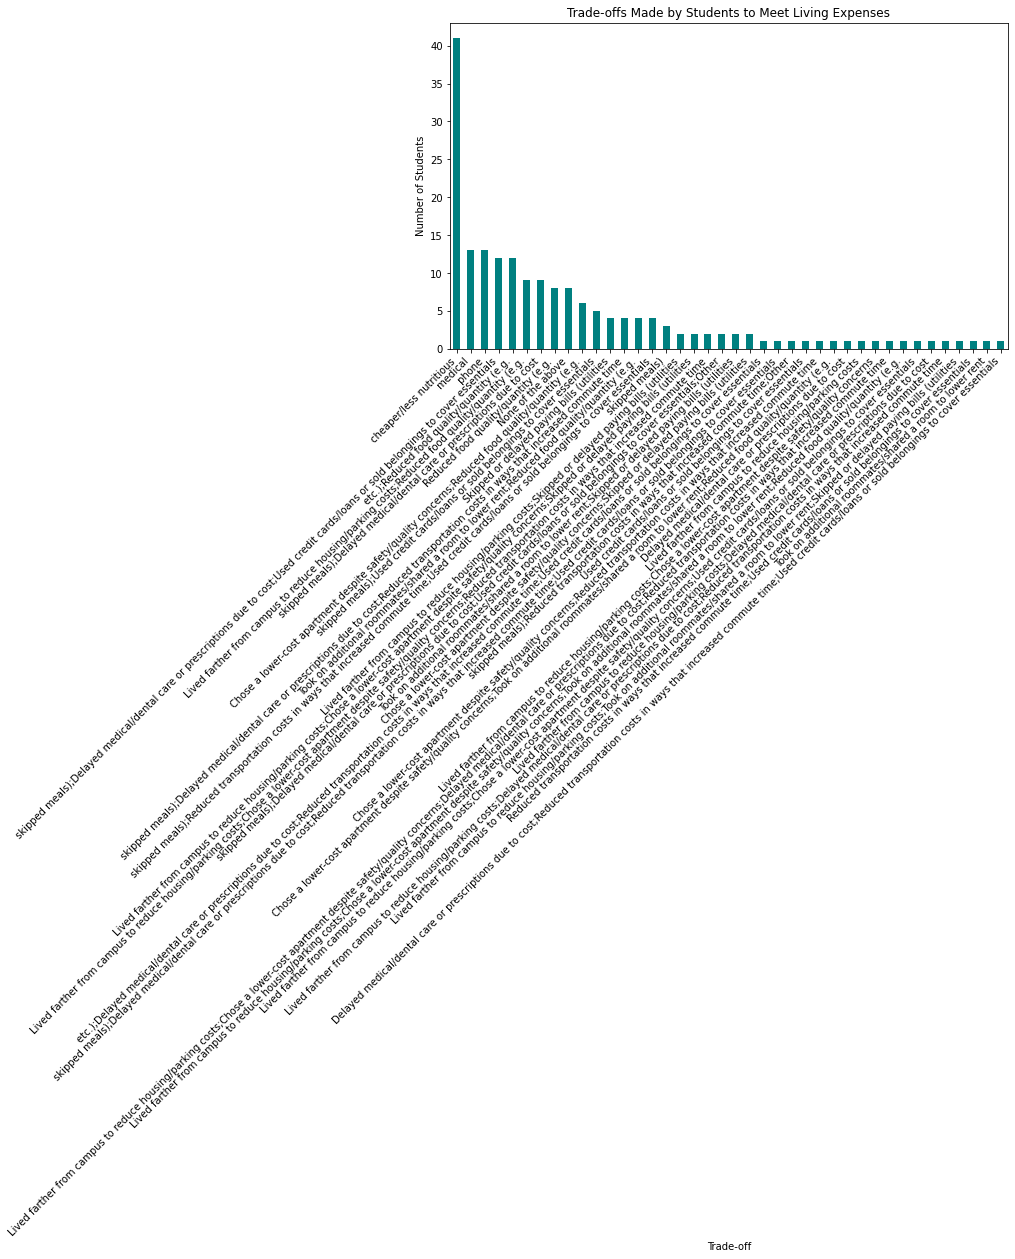

In [19]:
# Analysis of the trade-offs students made to meet living expenses in the past 12 months

tradeoffs_col = 'In_the_past_12_months,_which_of_the_following_trade-offs_have_you_made_to_meet_living_expenses_(Select_all_that_apply.)'

# Drop missing values and split multiple selections
tradeoffs = df[tradeoffs_col].dropna().str.get_dummies(sep=',')

# Sum up each trade-off option
tradeoff_counts = tradeoffs.sum().sort_values(ascending=False)

print("Trade-offs made by students to meet living expenses (count):")
print(tradeoff_counts)

# Plot the results
plt.figure(figsize=(10, 6), constrained_layout='True')
tradeoff_counts.plot(kind='bar', color="teal")
plt.title('Trade-offs Made by Students to Meet Living Expenses')
plt.ylabel('Number of Students')
plt.xlabel('Trade-off')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Performing Linear Regression so as to predict upcoming year housing payment from previous year payment

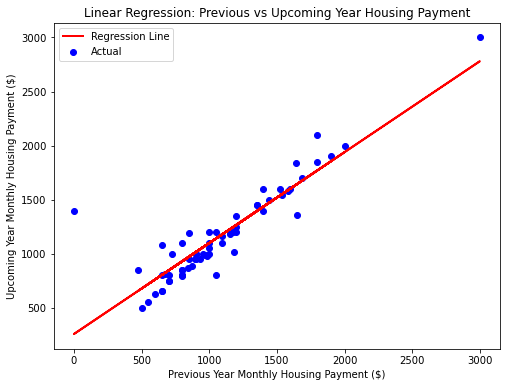

Regression Coefficient: 0.84
Regression Intercept: 258.46
R^2 Score: 0.80


In [20]:
# Prepare data, drop rows with missing values in relevant columns
reg_df = df[['What_was_your_individual_monthly_housing_payment_during_the_previous_year_(Base_cost;_no_utilities)',
             'What_is_your_individual_monthly_housing_payment_for_the_upcoming_year_(Base_cost;_no_utilities)']].dropna()

X = reg_df[['What_was_your_individual_monthly_housing_payment_during_the_previous_year_(Base_cost;_no_utilities)']].values
y = reg_df['What_is_your_individual_monthly_housing_payment_for_the_upcoming_year_(Base_cost;_no_utilities)'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Previous Year Monthly Housing Payment ($)')
plt.ylabel('Upcoming Year Monthly Housing Payment ($)')
plt.title('Linear Regression: Previous vs Upcoming Year Housing Payment')
plt.legend()
plt.show()

print(f"Regression Coefficient: {model.coef_[0]:.2f}")
print(f"Regression Intercept: {model.intercept_:.2f}")
print(f"R^2 Score: {model.score(X, y):.2f}")

The linear regression model predicts a student's upcoming year monthly housing payment based on their previous year's payment.
- The model uses the previous year's payment as the independent variable (X) and the upcoming year's payment as the dependent variable (y).
- After fitting the model, the regression coefficient indicates how much the upcoming payment is expected to change for each dollar change in the previous payment.
- The intercept represents the baseline upcoming payment when the previous payment is zero.
- The R² score shows how well the previous year's payment explains the variation in the upcoming year's payment (with 1.0 being a perfect fit).

**In this analysis**:
- A positive regression coefficient means indicates that students who paid more for housing last year are likely to pay more in the upcoming year as well.

### Recommendations to improve student funding
**1. Increase housing stipends** : Median housing costs are high and rising. Consider raising the base stipend to match the median rent plus utilities.

**2. Targeted support for international students** : International students may face higher housing costs and fewer funding options. Provide additional grants or subsidies.

**3. Food security programs** : Some students report high monthly food expenses, prefering to go for cheaper,less nutritious foods. Implement or expand food assistance programs or campus food pantries.

**4. Transportation subsidies** : Offer discounted transit passes or parking subsidies, as commuting costs vary widely.

**5. Emergency funds** : Create flexible emergency funding for students facing unexpected expenses (health, dependents, etc.).

In [21]:
df_renamed = df.rename(columns={
    'What_was_your_individual_monthly_housing_payment_during_the_previous_year_(Base_cost;_no_utilities)': 'Previous_Year_Housing',
    'What_is_your_individual_monthly_housing_payment_for_the_upcoming_year_(Base_cost;_no_utilities)': 'Upcoming_Year_Housing'
})


In [22]:
df_renamed.to_csv("housing_payments.csv", index=False)
